In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import matplotlib_fontja

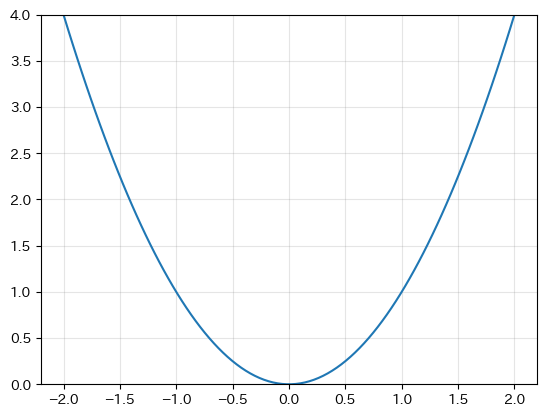

In [2]:
x = np.linspace(-2, 2, 100)
y = x**2
plt.plot(x,y)
plt.ylim(0,4)
plt.grid(c="gray",alpha=0.2)

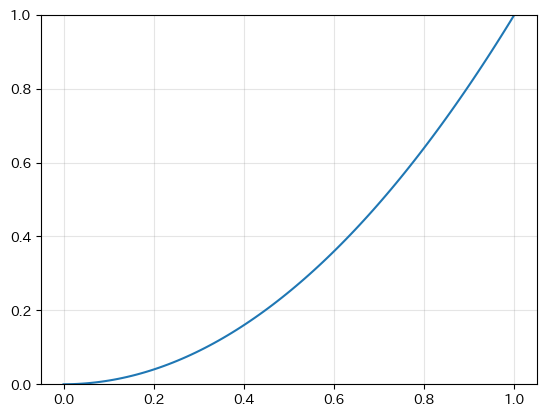

In [3]:
x = np.linspace(0, 1, 100)
y = x**2
plt.plot(x,y)
plt.ylim(0,1)
plt.grid(c="gray",alpha=0.2)

In [4]:
# データ入力
data = """
date,sales
2024-05-13,59
2024-05-20,78
2024-05-27,65
2024-06-03,79
2024-06-10,93
2024-06-17,77
2024-06-24,85
2024-07-01,135
2024-07-08,129
2024-07-15,142
2024-07-22,175
2024-07-29,165
2024-08-05,155
2024-08-12,117
2024-08-19,113
2024-08-26,80
2024-09-02,80
2024-09-09,90
2024-09-16,77
2024-09-23,67
2024-09-30,56
2024-10-07,43
2024-10-14,42
2024-10-21,38
2024-10-28,31
2024-11-04,37
2024-11-11,36
2024-11-18,35
2024-11-25,34
2024-12-02,34
2024-12-09,39
2024-12-16,48
2024-12-23,54
2024-12-30,51
2025-01-06,42
2025-01-13,34
2025-01-20,31
2025-01-27,28
2025-02-03,28
2025-02-10,31
2025-02-17,29
2025-02-24,32
2025-03-03,31
2025-03-10,33
2025-03-17,38
2025-03-24,38
2025-03-31,32
2025-04-07,36
2025-04-14,47
2025-04-21,47
2025-04-28,50
2025-05-05,49
2025-05-12,57
2025-05-19,70
2025-05-26,56
2025-06-02,73
2025-06-09,65
2025-06-16,128
2025-06-23,117
2025-06-30,139
2025-07-07,131
2025-07-14,113
2025-07-21,147
2025-07-28,130
2025-08-04,120
2025-08-11,89
2025-08-18,116
2025-08-25,109
2025-09-01,87
2025-09-08,74
2025-09-15,71
2025-09-22,60
2025-09-29,50
2025-10-06,44
2025-10-13,40
2025-10-20,35
2025-10-27,37
2025-11-03,37
2025-11-10,40
2025-11-17,39
2025-11-24,39
2025-12-01,41
2025-12-08,32
2025-12-15,35
2025-12-22,33
2025-12-29,28
2026-01-05,32
2026-01-12,31
2026-01-19,31
2026-01-26,36
2026-02-02,38
2026-02-09,40
2026-02-16,38
2026-02-23,35
2026-03-02,32
2026-03-09,32
2026-03-16,35
2026-03-23,34
2026-03-30,31
2026-04-06,35
2026-04-13,40
2026-04-20,44
2026-04-27,51
2026-05-04,58
"""

from io import StringIO

df = pd.read_csv(StringIO(data))
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# 週次データとして頻度を明示
y = df["sales"].asfreq("W-MON")

# 確認
print(y.head())
print(y.tail())

date
2024-05-13    59
2024-05-20    78
2024-05-27    65
2024-06-03    79
2024-06-10    93
Freq: W-MON, Name: sales, dtype: int64
date
2026-04-06    35
2026-04-13    40
2026-04-20    44
2026-04-27    51
2026-05-04    58
Freq: W-MON, Name: sales, dtype: int64


In [5]:
# 非季節ARIMA(1,1,1)
model_arima = SARIMAX(
    y,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_arima = model_arima.fit(disp=False)

print(result_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  104
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -406.717
Date:                Mon, 01 Jun 2026   AIC                            819.435
Time:                        09:07:56   BIC                            827.280
Sample:                    05-13-2024   HQIC                           822.611
                         - 05-04-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4605      0.383     -1.202      0.229      -1.211       0.290
ma.L1          0.3476      0.434      0.800      0.424      -0.504       1.199
sigma2       184.1556     13.579     13.562      0.0

In [6]:
import numpy as np

y_log = np.log(y)

model_log = SARIMAX(
    y_log,
    order=(1, 1, 1),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_log = model_log.fit(disp=False)
print(result_log.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  104
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  42.660
Date:                Mon, 01 Jun 2026   AIC                            -79.319
Time:                        09:07:57   BIC                            -71.474
Sample:                    05-13-2024   HQIC                           -76.143
                         - 05-04-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8000      0.208      3.855      0.000       0.393       1.207
ma.L1         -0.7271      0.240     -3.024      0.002      -1.198      -0.256
sigma2         0.0251      0.003      9.547      0.0

In [7]:
forecast_log = result_log.get_forecast(steps=12)
forecast_mean_log = forecast_log.predicted_mean
forecast_ci_log = forecast_log.conf_int()

forecast_mean = np.exp(forecast_mean_log)
forecast_ci = np.exp(forecast_ci_log)

print(forecast_mean)
print(forecast_ci)

2026-05-11    59.505793
2026-05-18    60.738575
2026-05-25    61.743205
2026-06-01    62.558891
2026-06-08    63.219219
2026-06-15    63.752517
2026-06-22    64.182410
2026-06-29    64.528425
2026-07-06    64.806590
2026-07-13    65.029994
2026-07-20    65.209279
2026-07-27    65.353068
Freq: W-MON, Name: predicted_mean, dtype: float64
            lower sales  upper sales
2026-05-11    43.628880    81.160446
2026-05-18    38.528002    95.753072
2026-05-25    34.747874   109.710980
2026-06-01    31.653328   123.639918
2026-06-08    29.017604   137.732588
2026-06-15    26.727286   152.068694
2026-06-22    24.713331   166.686628
2026-06-29    22.928087   181.607717
2026-07-06    21.335943   196.845954
2026-07-13    19.908925   212.412277
2026-07-20    18.624364   228.316520
2026-07-27    17.463521   244.568287


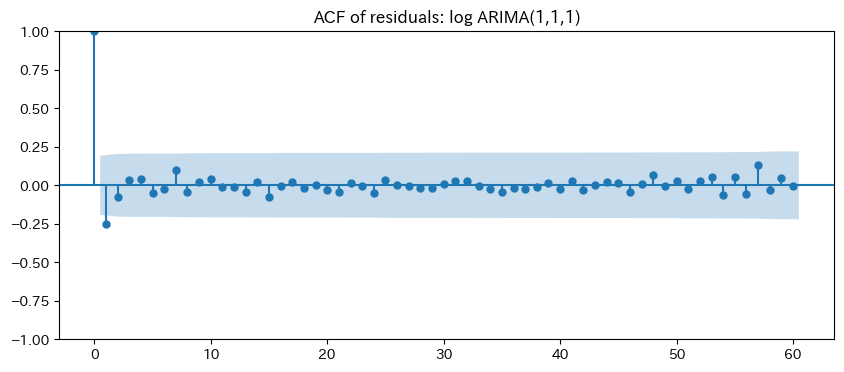

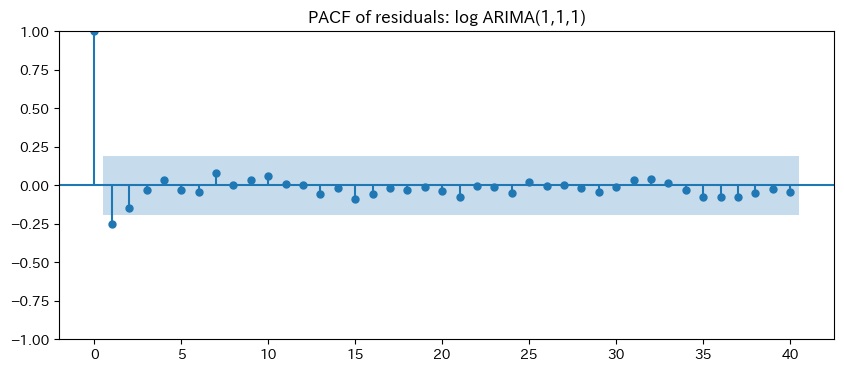

In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

resid = result_log.resid.dropna()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid, lags=60, ax=ax)
ax.set_title("ACF of residuals: log ARIMA(1,1,1)")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(resid, lags=40, ax=ax, method="ywm")
ax.set_title("PACF of residuals: log ARIMA(1,1,1)")
plt.show()

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    resid,
    lags=[1, 4, 8, 12, 26, 52],
    return_df=True
)

print(lb)

      lb_stat  lb_pvalue
1    6.619702   0.010086
4    7.531948   0.110309
8    9.290548   0.318382
12   9.595249   0.651422
26  11.730713   0.992590
52  14.801332   1.000000


In [10]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fourier_terms(index, period=52.18, K=2):
    t = np.arange(len(index))
    terms = {}
    for k in range(1, K + 1):
        terms[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        terms[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(terms, index=index)

y_log = np.log(y)

X = fourier_terms(y_log.index, period=52.18, K=2)

model_log_fourier = SARIMAX(
    y_log,
    exog=X,
    order=(1, 0, 1),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_log_fourier = model_log_fourier.fit(disp=False)

print(result_log_fourier.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  104
Model:               SARIMAX(1, 0, 1)   Log Likelihood                  67.138
Date:                Mon, 01 Jun 2026   AIC                           -118.276
Time:                        09:07:57   BIC                            -97.277
Sample:                    05-13-2024   HQIC                          -109.773
                         - 05-04-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.2935      0.726      3.157      0.002       0.870       3.717
sin_1          0.6002      0.038     15.963      0.000       0.527       0.674
cos_1          0.2446      0.039      6.252      0.0

In [11]:
model_log_fourier_ar1 = SARIMAX(
    y_log,
    exog=X,
    order=(1, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_log_fourier_ar1 = model_log_fourier_ar1.fit(disp=False)

print(result_log_fourier_ar1.summary())
model_log_fourier_ma1 = SARIMAX(
    y_log,
    exog=X,
    order=(0, 0, 1),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_log_fourier_ma1 = model_log_fourier_ma1.fit(disp=False)

print(result_log_fourier_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  104
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  67.407
Date:                Mon, 01 Jun 2026   AIC                           -120.815
Time:                        09:07:57   BIC                           -102.372
Sample:                    05-13-2024   HQIC                          -113.345
                         - 05-04-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.0793      0.315      6.596      0.000       1.461       2.697
sin_1          0.6015      0.039     15.378      0.000       0.525       0.678
cos_1          0.2511      0.041      6.151      0.0

In [12]:
models = {
    "log ARIMA(1,1,1)": result_log,
    "log Fourier K=2 + ARMA(1,1)": result_log_fourier,
    "log Fourier K=2 + AR(1)": result_log_fourier_ar1,
    "log Fourier K=2 + MA(1)": result_log_fourier_ma1,
}

for name, res in models.items():
    print(
        name,
        "AIC:", round(res.aic, 3),
        "BIC:", round(res.bic, 3)
    )

log ARIMA(1,1,1) AIC: -79.319 BIC: -71.474
log Fourier K=2 + ARMA(1,1) AIC: -118.276 BIC: -97.277
log Fourier K=2 + AR(1) AIC: -120.815 BIC: -102.372
log Fourier K=2 + MA(1) AIC: -115.561 BIC: -97.187


In [13]:
print(result_log_fourier_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  104
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  67.407
Date:                Mon, 01 Jun 2026   AIC                           -120.815
Time:                        09:07:57   BIC                           -102.372
Sample:                    05-13-2024   HQIC                          -113.345
                         - 05-04-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.0793      0.315      6.596      0.000       1.461       2.697
sin_1          0.6015      0.039     15.378      0.000       0.525       0.678
cos_1          0.2511      0.041      6.151      0.0

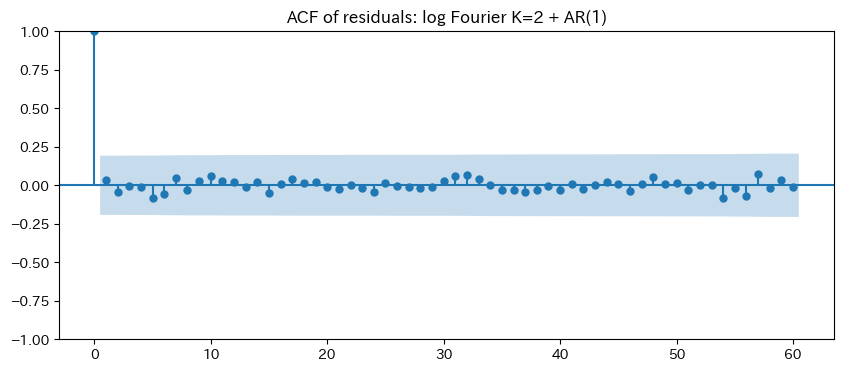

     lb_stat  lb_pvalue
1   0.140818   0.707469
4   0.358892   0.985702
8   1.837493   0.985595
12  2.427845   0.998411
26  3.591119   1.000000
52  7.383499   1.000000


In [14]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = result_log_fourier_ar1.resid.dropna()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid, lags=60, ax=ax)
ax.set_title("ACF of residuals: log Fourier K=2 + AR(1)")
plt.show()

lb = acorr_ljungbox(
    resid,
    lags=[1, 4, 8, 12, 26, 52],
    return_df=True
)

print(lb)

In [15]:
import numpy as np
import pandas as pd

def fourier_terms(index, period=52.18, K=2):
    t = np.arange(len(index))
    terms = {}
    for k in range(1, K + 1):
        terms[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        terms[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(terms, index=index)

# 12週先を予測
steps = 12

future_index = pd.date_range(
    start=y.index[-1] + pd.Timedelta(weeks=1),
    periods=steps,
    freq="W-MON"
)

full_index = y.index.append(future_index)

X_full = fourier_terms(full_index, period=52.18, K=2)
X_future = X_full.loc[future_index]

forecast_log = result_log_fourier_ar1.get_forecast(
    steps=steps,
    exog=X_future
)

forecast_mean_log = forecast_log.predicted_mean
forecast_ci_log = forecast_log.conf_int()

# 本数スケールへ戻す
forecast_mean = np.exp(forecast_mean_log)
forecast_ci = np.exp(forecast_ci_log)

forecast_df = pd.DataFrame({
    "forecast": forecast_mean,
    "lower": forecast_ci.iloc[:, 0],
    "upper": forecast_ci.iloc[:, 1],
})

print(forecast_df)

              forecast       lower       upper
2026-05-11   60.417426   47.219196   77.304692
2026-05-18   65.838430   50.099512   86.521778
2026-05-25   73.285371   55.446709   96.863199
2026-06-01   82.184386   62.099011  108.766198
2026-06-08   92.025532   69.514497  121.826367
2026-06-15  102.223081   77.212339  135.335342
2026-06-22  112.072829   84.650861  148.377923
2026-06-29  120.780234   91.227418  159.906587
2026-07-06  127.546344   96.337901  168.864691
2026-07-13  131.690103   99.467734  174.350843
2026-07-20  132.772900  100.285584  175.784417
2026-07-27  130.686055   98.709354  173.021544


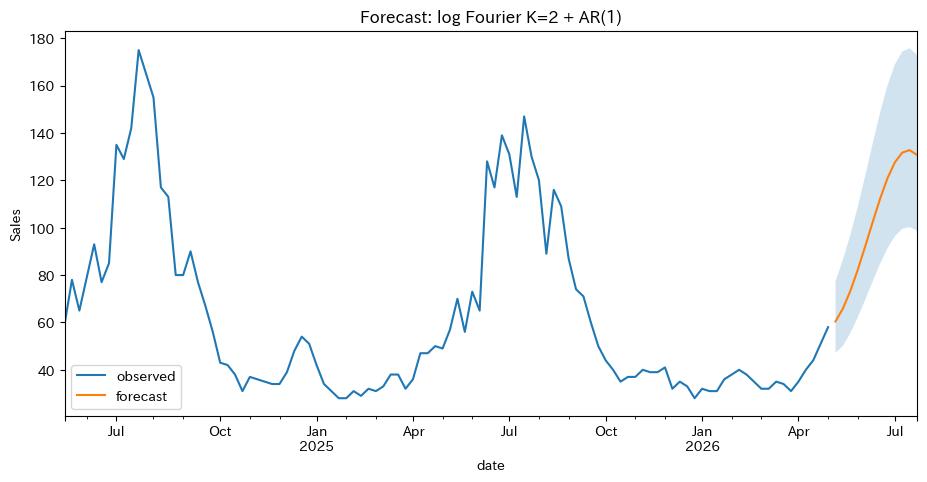

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

y.plot(ax=ax, label="observed")
forecast_df["forecast"].plot(ax=ax, label="forecast")

ax.fill_between(
    forecast_df.index,
    forecast_df["lower"],
    forecast_df["upper"],
    alpha=0.2
)

ax.set_title("Forecast: log Fourier K=2 + AR(1)")
ax.set_ylabel("Sales")
ax.legend()

plt.show()

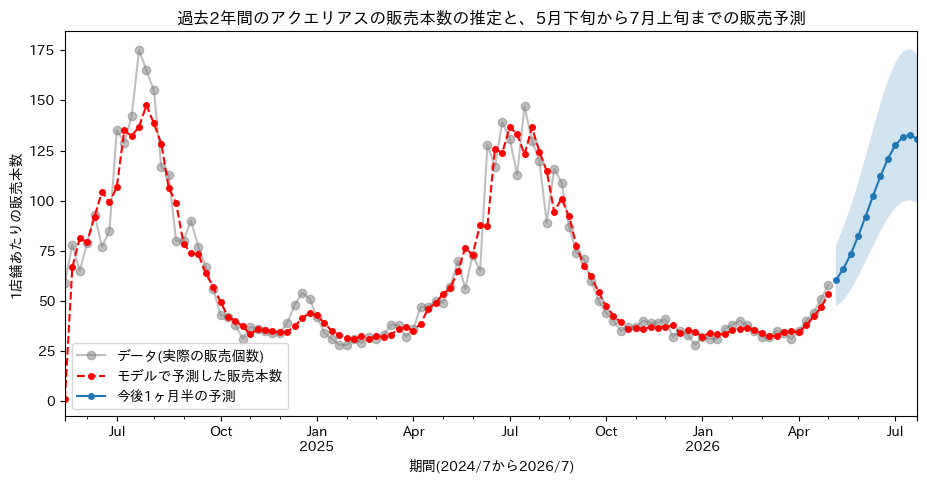

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja

# in-sample fitted values
fitted_log = result_log_fourier_ar1.fittedvalues

# 本数スケールに戻す
fitted = np.exp(fitted_log)

fig, ax = plt.subplots(figsize=(11, 5))

# 実測値
y.plot(ax=ax, label="データ(実際の販売個数)", c="gray", marker="o", alpha=0.5)

# in-sample fitted line
fitted_plot = fitted.copy()
fitted_plot.iloc[:2] = np.nan

fitted.plot(ax=ax, label="モデルで予測した販売本数", linestyle="--", c="red", marker="o", markersize=4)


# out-of-sample forecast
forecast_df["forecast"].plot(ax=ax, label="今後1ヶ月半の予測", marker="o", markersize=4)

ax.fill_between(
    forecast_df.index,
    forecast_df["lower"],
    forecast_df["upper"],
    alpha=0.2
)

ax.set_title("Observed, In-sample fitted, and Forecast: log Fourier K=2 + AR(1)")
ax.set_title("過去2年間のアクエリアスの販売本数の推定と、5月下旬から7月上旬までの販売予測")

ax.set_ylabel("1店舗あたりの販売本数")
ax.set_xlabel('期間(2024/7から2026/7)')
ax.legend()

plt.show()

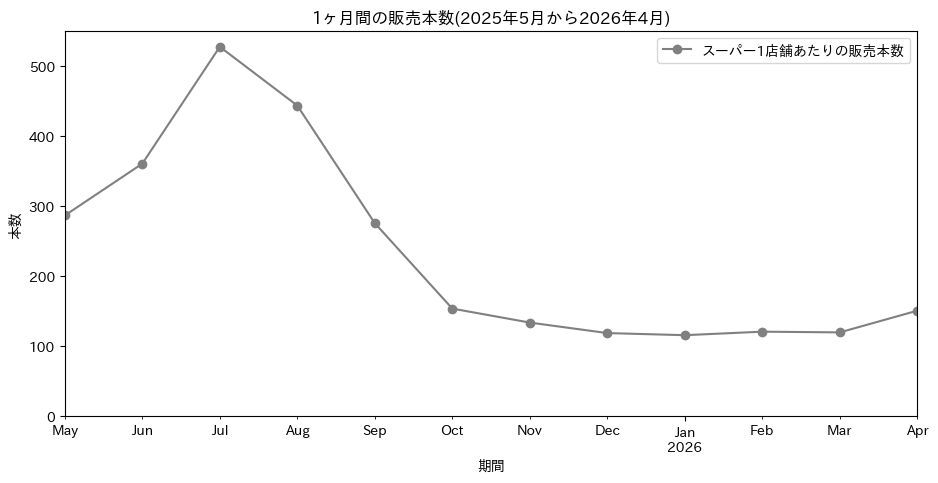

In [18]:
mdata = """
年月	本数
2025-05	287
2025-06	361
2025-07	528
2025-08	444
2025-09	276
2025-10	154
2025-11	134
2025-12	119
2026-01	116
2026-02	121
2026-03	120
2026-04	151
"""
dfm = pd.read_csv(StringIO(mdata), delimiter="\t")
dfm["年月"] = pd.to_datetime(dfm["年月"])
dfm = dfm.set_index("年月")

# 週次データとして頻度を明示
y = dfm["本数"].asfreq("ME")
fig, ax=plt.subplots(1,1,figsize=(11,5))
dfm.plot(marker="o", c="gray",ax=ax)
plt.legend(["スーパー1店舗あたりの販売本数"])
plt.xlabel("期間")
plt.ylim(0, 550)
plt.ylabel("本数")
plt.title('1ヶ月間の販売本数(2025年5月から2026年4月)')
plt.show()

$$
\frac{増えた分}{もとの本数}
$$
いきなり
$$
\frac{\text{後の値}-\text{前の値}}{\text{前の値}}
$$
と書くより、最初は
$$
\frac{増えた分}{もとの本数}
$$
の方が直感的です。具体例は1つだけでよいです。
$$
\frac{74}{287}\approx0.258
$$
つまり、

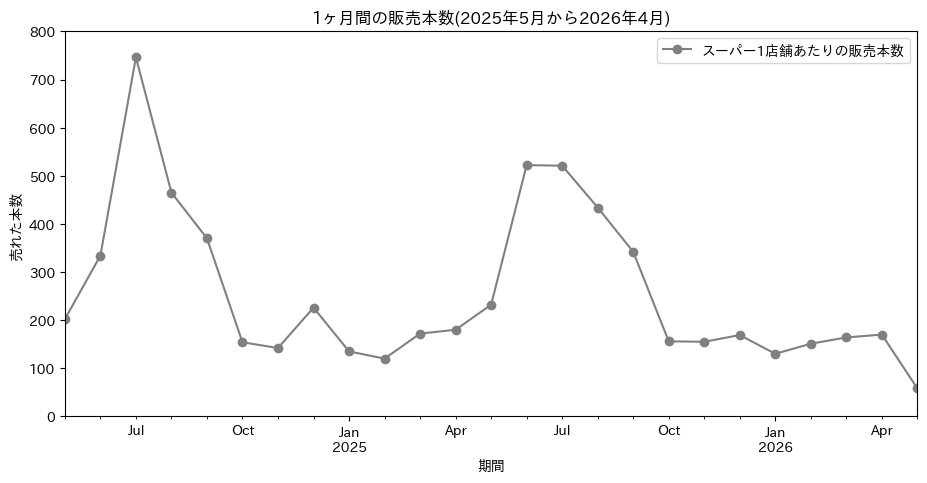

In [19]:
fig, ax=plt.subplots(1,1,figsize=(11,5))
df.resample('ME').sum().plot(marker="o", c="gray", ax=ax)
plt.legend(["スーパー1店舗あたりの販売本数"])
plt.xlabel("期間")
plt.ylim(0, 800)
plt.ylabel("売れた本数")
plt.title('1ヶ月間の販売本数(2025年5月から2026年4月)')
plt.show()

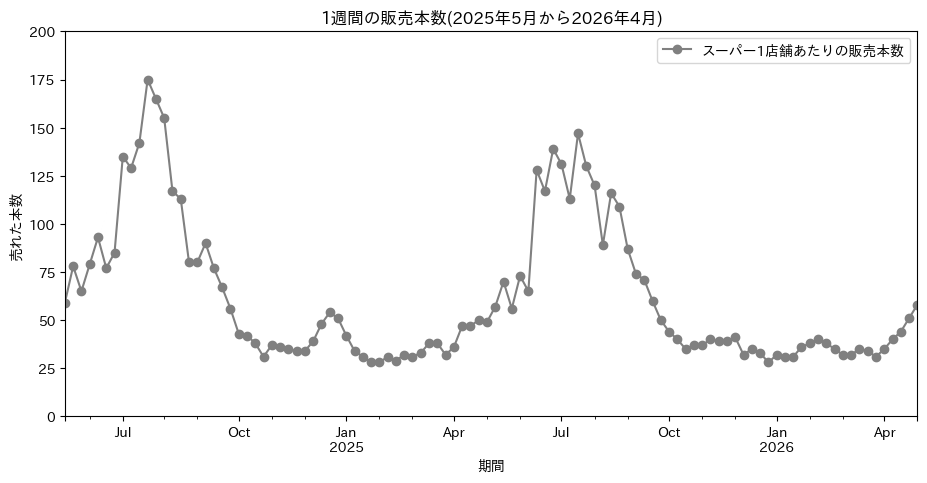

In [20]:
fig, ax=plt.subplots(1,1,figsize=(11,5))
df.plot(marker="o", c="gray", ax=ax)
plt.legend(["スーパー1店舗あたりの販売本数"])
plt.xlabel("期間")
plt.ylim(0, 200)
plt.ylabel("売れた本数")
plt.title('1週間の販売本数(2025年5月から2026年4月)')
plt.show()

In [21]:
df.resample('ME').sum().to_clipboard()

In [22]:
dfm

,本数
年月,
2025-05-01,287
2025-06-01,361
2025-07-01,528
2025-08-01,444
2025-09-01,276
2025-10-01,154
2025-11-01,134
2025-12-01,119
2026-01-01,116
